# Symbolic Unconditioned Music Generation
**CSE 153/253 — Assignment 2**

## 1. Setup

In [1]:
#!pip install pretty_midi

import pretty_midi
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import random
from tqdm.auto import tqdm
from collections import Counter


## 2. Configuration

In [2]:
# ── Paths (Google Colab + Google Drive) ───────────────────────────────────────
LMD_FULL_DIR      = Path("lmd_full")                          # extracted locally for speed
FILTERED_DIR      = Path("lmd_full_filtered")   # persists on Drive
TRAIN_TOKENS_PATH = Path("train_tokens.npy")    # persists on Drive
VAL_TOKENS_PATH   = Path("val_tokens.npy")      # persists on Drive
# ──────────────────────────────────────────────────────────────────────────────


In [3]:
# from google.colab import drive
# drive.mount("/content/drive")


In [4]:
# import tarfile

# tar_path = "/content/drive/MyDrive/CSE153A2/lmd_full.tar.gz"

# if not LMD_FULL_DIR.exists():
#     print("Extracting lmd_full.tar.gz to /content/lmd_full ...")
#     with tarfile.open(tar_path, "r:gz") as tar:
#         tar.extractall("/content/")
#     print("Extraction complete.")
# else:
#     print(f"lmd_full already extracted at {LMD_FULL_DIR}")


## 3. Tokenizer

In [5]:
# vocabulary constants
NOTE_ON_OFFSET    = 0
NOTE_OFF_OFFSET   = 128
TIME_SHIFT_OFFSET = 256
VELOCITY_OFFSET   = 356
INSTRUMENT_OFFSET = 388   # PIANO=388, VIOLIN=389

CC_MODULATION_OFFSET = 390  
CC_EXPRESSION_OFFSET = CC_MODULATION_OFFSET + 128 
PITCH_BEND_OFFSET    = CC_EXPRESSION_OFFSET + 128 
VOCAB_SIZE           = PITCH_BEND_OFFSET + 128

N_TIME_SHIFT_BINS = 100
N_VELOCITY_BINS   = 32
TIME_STEP_MS      = 10
MAX_SHIFT_MS      = N_TIME_SHIFT_BINS * TIME_STEP_MS

PIANO_TOKEN  = 388
VIOLIN_TOKEN = 389

def velocity_to_bin(velocity):
    return min(velocity // 4, N_VELOCITY_BINS - 1)

def bin_to_velocity(bin_idx):
    return bin_idx * 4 + 2

In [6]:
def get_instrument_token(instrument):
    name = instrument.name.lower()
    program = instrument.program
    # violin: program 40, viola: 41, cello: 42
    if program in range(40, 48) or "violin" in name:
        return VIOLIN_TOKEN
    return PIANO_TOKEN

def midi_to_tokens(midi_path):
    midi = pretty_midi.PrettyMIDI(str(midi_path))

    # Step 1: collect raw events, tagging each note with its instrument token
    raw_events = []
    note_id = 0  # Tracker to keep note properties grouped
    
    for instrument in midi.instruments:
        inst_token = get_instrument_token(instrument)
        for note in instrument.notes:
            vbin = velocity_to_bin(note.velocity)
            # 5-item tuple -> (time, instrument, note_id, type, value)
            raw_events.append((note.start, inst_token, note_id, 'INSTRUMENT', inst_token))
            raw_events.append((note.start, inst_token, note_id, 'VELOCITY',   vbin))
            raw_events.append((note.start, inst_token, note_id, 'NOTE_ON',    note.pitch))
            raw_events.append((note.end,   inst_token, note_id, 'NOTE_OFF',   note.pitch))
            note_id += 1
            
        for cc in instrument.control_changes:
            if cc.number == 1: 
                raw_events.append((cc.time, inst_token, note_id, 'CC_MODULATION', cc.value))
            elif cc.number == 11: 
                raw_events.append((cc.time, inst_token, note_id, 'CC_EXPRESSION', cc.value))
            note_id += 1
            
        for pb in instrument.pitch_bends:
            scaled_bend = int((pb.pitch + 8192) / 16384 * 127)
            raw_events.append((pb.time, inst_token, note_id, 'PITCH_BEND', scaled_bend))
            note_id += 1

    # Step 2: sort by time -> instrument -> note_id -> event type
    type_order = {'INSTRUMENT': 0, 'VELOCITY': 1, 'NOTE_ON': 2, 'NOTE_OFF': 3, 
              'CC_MODULATION': 4, 'CC_EXPRESSION': 5, 'PITCH_BEND': 6}
    raw_events.sort(key=lambda e: (e[0], e[1], e[2], type_order[e[3]]))

    # Step 3: convert to tokens
    tokens = []
    current_time = 0.0

    # Unpack 5 variables
    for event_time, _, _, event_type, value in raw_events:
        delta_ms = int(round((event_time - current_time) * 1000))

        while delta_ms > 0:
            shift   = min(delta_ms, MAX_SHIFT_MS)
            n_steps = max(1, int(round(shift / TIME_STEP_MS)))
            n_steps = min(n_steps, N_TIME_SHIFT_BINS)
            tokens.append(TIME_SHIFT_OFFSET + n_steps - 1)
            delta_ms -= n_steps * TIME_STEP_MS

        current_time = event_time

        if event_type == 'NOTE_ON':
            tokens.append(NOTE_ON_OFFSET + value)
        elif event_type == 'NOTE_OFF':
            tokens.append(NOTE_OFF_OFFSET + value)
        elif event_type == 'VELOCITY':
            tokens.append(VELOCITY_OFFSET + value)
        elif event_type == 'INSTRUMENT':
            tokens.append(value)
        elif event_type == 'CC_MODULATION':
            tokens.append(CC_MODULATION_OFFSET + value)
        elif event_type == 'CC_EXPRESSION':
            tokens.append(CC_EXPRESSION_OFFSET + value)
        elif event_type == 'PITCH_BEND':
            tokens.append(PITCH_BEND_OFFSET + value)
            
    # Clean up consecutive duplicate instrument tokens
    clean_tokens = []
    for t in tokens:
        if t in [PIANO_TOKEN, VIOLIN_TOKEN] and clean_tokens and clean_tokens[-1] == t:
            continue
        clean_tokens.append(t)
        
    return clean_tokens

In [7]:
def tokens_to_midi(tokens, output_path):
    midi   = pretty_midi.PrettyMIDI()
    piano  = pretty_midi.Instrument(program=0,  name="Piano")
    violin = pretty_midi.Instrument(program=40, name="Violin")

    current_time        = 0.0
    current_velocity    = bin_to_velocity(16)
    current_instrument  = PIANO_TOKEN
    open_notes          = {}  # (pitch, instrument) → (start_time, velocity)

    for token in tokens:
        if token == PIANO_TOKEN or token == VIOLIN_TOKEN:
            current_instrument = token

        elif NOTE_ON_OFFSET <= token < NOTE_OFF_OFFSET:
            pitch = token - NOTE_ON_OFFSET
            open_notes[(pitch, current_instrument)] = (current_time, current_velocity)

        elif NOTE_OFF_OFFSET <= token < TIME_SHIFT_OFFSET:
            pitch = token - NOTE_OFF_OFFSET
            for inst in [current_instrument, PIANO_TOKEN, VIOLIN_TOKEN]:
                key = (pitch, inst)
                if key in open_notes:
                    start, vel = open_notes.pop(key)
                    end  = max(current_time, start + 0.01)
                    note = pretty_midi.Note(velocity=vel, pitch=pitch, start=start, end=end)
                    if inst == PIANO_TOKEN:
                        piano.notes.append(note)
                    else:
                        violin.notes.append(note)
                    break

        elif TIME_SHIFT_OFFSET <= token < VELOCITY_OFFSET:
            n_steps = token - TIME_SHIFT_OFFSET + 1
            current_time += n_steps * TIME_STEP_MS / 1000.0

        elif VELOCITY_OFFSET <= token < INSTRUMENT_OFFSET:
            current_velocity = bin_to_velocity(token - VELOCITY_OFFSET)
            
        elif CC_MODULATION_OFFSET <= token < CC_EXPRESSION_OFFSET:
            val = token - CC_MODULATION_OFFSET
            cc = pretty_midi.ControlChange(number=1, value=val, time=current_time)
            if current_instrument == PIANO_TOKEN:
                piano.control_changes.append(cc)
            else:
                violin.control_changes.append(cc)
                
        elif CC_EXPRESSION_OFFSET <= token < PITCH_BEND_OFFSET:
            val = token - CC_EXPRESSION_OFFSET
            cc = pretty_midi.ControlChange(number=11, value=val, time=current_time)
            if current_instrument == PIANO_TOKEN:
                piano.control_changes.append(cc)
            else:
                violin.control_changes.append(cc)
                
        elif PITCH_BEND_OFFSET <= token < VOCAB_SIZE:
            val = token - PITCH_BEND_OFFSET
            pitch_val = int((val / 127.0 * 16384) - 8192)
            pb = pretty_midi.PitchBend(pitch=pitch_val, time=current_time)
            if current_instrument == PIANO_TOKEN:
                piano.pitch_bends.append(pb)
            else:
                violin.pitch_bends.append(pb)

    # close any notes still open at the end
    for (pitch, inst), (start, vel) in open_notes.items():
        note = pretty_midi.Note(velocity=vel, pitch=pitch,
                                start=start, end=max(current_time, start + 0.01))
        if inst == PIANO_TOKEN:
            piano.notes.append(note)
        else:
            violin.notes.append(note)

    midi.instruments.append(piano)
    midi.instruments.append(violin)
    midi.write(str(output_path))
    print(f"Saved: {output_path} | piano notes: {len(piano.notes)} | violin notes: {len(violin.notes)}")

## 4. Sanity Check

In [8]:
# Create a simple hand-crafted MIDI: piano plays C4, violin plays E4 simultaneously
test_midi  = pretty_midi.PrettyMIDI()
piano_inst = pretty_midi.Instrument(program=0,  name="Piano")
violin_inst= pretty_midi.Instrument(program=40, name="Violin")
piano_inst.notes.append( pretty_midi.Note(velocity=80, pitch=60, start=0.0, end=0.5))
violin_inst.notes.append(pretty_midi.Note(velocity=70, pitch=64, start=0.0, end=0.5))
piano_inst.notes.append( pretty_midi.Note(velocity=75, pitch=62, start=0.5, end=1.0))
violin_inst.notes.append(pretty_midi.Note(velocity=65, pitch=67, start=0.5, end=1.0))
test_midi.instruments.append(piano_inst)
test_midi.instruments.append(violin_inst)
test_midi.write("test_input.mid")

# Tokenize it
tokens = midi_to_tokens("test_input.mid")

# Print tokens with human-readable labels
def decode_token(t):
    if t == PIANO_TOKEN:
        return "INSTRUMENT(PIANO)"
    elif t == VIOLIN_TOKEN:
        return "INSTRUMENT(VIOLIN)"
    elif t < NOTE_OFF_OFFSET:
        return f"NOTE_ON({t})"
    elif t < TIME_SHIFT_OFFSET:
        return f"NOTE_OFF({t - NOTE_OFF_OFFSET})"
    elif t < VELOCITY_OFFSET:
        return f"TIME_SHIFT({(t - TIME_SHIFT_OFFSET + 1) * TIME_STEP_MS}ms)"
        
    # --- FIXED BOUNDARY FOR VELOCITY ---
    elif t < INSTRUMENT_OFFSET:
        return f"VELOCITY(bin={t - VELOCITY_OFFSET})"
        
    # --- NEW: DECODING VIOLIN EXPRESSIONS ---
    elif t < CC_EXPRESSION_OFFSET:
        return f"CC_MODULATION({t - CC_MODULATION_OFFSET})"
    elif t < PITCH_BEND_OFFSET:
        return f"CC_EXPRESSION({t - CC_EXPRESSION_OFFSET})"
    else:
        return f"PITCH_BEND({t - PITCH_BEND_OFFSET})"

print(f"Tokens ({len(tokens)} total):")
for t in tokens:
    print(f"  {t:3d}  →  {decode_token(t)}")

# Round-trip check
tokens_to_midi(tokens, "test_roundtrip.mid")
tokens_rt = midi_to_tokens("test_roundtrip.mid")
print(f"\nRound-trip match: {tokens == tokens_rt}")

Tokens (18 total):
  388  →  INSTRUMENT(PIANO)
  376  →  VELOCITY(bin=20)
   60  →  NOTE_ON(60)
  389  →  INSTRUMENT(VIOLIN)
  373  →  VELOCITY(bin=17)
   64  →  NOTE_ON(64)
  305  →  TIME_SHIFT(500ms)
  188  →  NOTE_OFF(60)
  388  →  INSTRUMENT(PIANO)
  374  →  VELOCITY(bin=18)
   62  →  NOTE_ON(62)
  192  →  NOTE_OFF(64)
  389  →  INSTRUMENT(VIOLIN)
  372  →  VELOCITY(bin=16)
   67  →  NOTE_ON(67)
  305  →  TIME_SHIFT(500ms)
  190  →  NOTE_OFF(62)
  195  →  NOTE_OFF(67)
Saved: test_roundtrip.mid | piano notes: 2 | violin notes: 2

Round-trip match: True


## 5. Data Loading

### Dataset: Lakh MIDI Dataset (LMD Full)

The [Lakh MIDI Dataset](https://colinraffel.com/projects/lmd/) (LMD) is a collection of 176,581 unique MIDI files compiled by Colin Raffel as part of his PhD thesis. It was assembled by matching MIDI files scraped from the internet against the Million Song Dataset, making it one of the largest publicly available symbolic music corpora. The files span a wide range of genres including pop, rock, jazz, and classical.

**Why piano + violin?**  
We focus on piano (GM programs 0–7) and violin/strings (GM programs 40–47) for two reasons. First, this pairing produces a natural melodic and harmonic interplay — the violin typically carries the melody while the piano provides harmonic support. Second, restricting to exactly these two instrument families produces a cleaner, more consistent training distribution compared to training on arbitrary multi-track arrangements.

After filtering for files containing *only* piano and violin instruments, we retain a focused subset suitable for learning the joint distribution of a piano+violin duo.


In [9]:
import shutil

def has_piano_and_violin(midi_path):
    try:
        midi = pretty_midi.PrettyMIDI(str(midi_path))
        programs = [i.program for i in midi.instruments if not i.is_drum]
        has_piano  = any(p in range(0, 8)  for p in programs)
        has_violin = any(p in range(40, 48) for p in programs)
        return has_piano and has_violin
    except:
        return False

if FILTERED_DIR.exists():
    print(f"Filtered dataset already exists at {FILTERED_DIR}/")
else:
    FILTERED_DIR.mkdir()
    all_midi = list(LMD_FULL_DIR.rglob("*.mid"))
    print(f"Total MIDI files: {len(all_midi):,}")
    print("Filtering for files containing piano + violin...")
    copied = 0
    for i, path in enumerate(all_midi):
        if has_piano_and_violin(path):
            shutil.copy(path, FILTERED_DIR / path.name)
            copied += 1
        if (i + 1) % 5000 == 0:
            print(f"  {i+1:,}/{len(all_midi):,} scanned | {copied} copied")
    print(f"Done — {copied} files saved to {FILTERED_DIR}/")

filtered = list(FILTERED_DIR.rglob("*.mid"))
print(f"Files in filtered dataset: {len(filtered):,}")


Filtered dataset already exists at lmd_full_filtered/
Files in filtered dataset: 19,929


## 5.1 Exploratory Data Analysis

In [ ]:
# Analyze the filtered piano+violin files
durations   = []
piano_notes = []
violin_notes= []
programs_seen = []

for path in filtered:
    try:
        midi = pretty_midi.PrettyMIDI(str(path))
        durations.append(midi.get_end_time())
        p_notes, v_notes = 0, 0
        for inst in midi.instruments:
            if inst.is_drum:
                continue
            programs_seen.append(inst.program)
            if inst.program in range(0, 8):
                p_notes += len(inst.notes)
            elif inst.program in range(40, 48):
                v_notes += len(inst.notes)
        piano_notes.append(p_notes)
        violin_notes.append(v_notes)
    except:
        pass

durations    = np.array(durations)
piano_notes  = np.array(piano_notes)
violin_notes = np.array(violin_notes)

print(f"Files analyzed      : {len(durations)}")
print(f"Duration  — mean: {durations.mean():.1f}s  median: {np.median(durations):.1f}s  max: {durations.max():.1f}s")
print(f"Piano notes/file  — mean: {piano_notes.mean():.0f}  median: {np.median(piano_notes):.0f}")
print(f"Violin notes/file — mean: {violin_notes.mean():.0f}  median: {np.median(violin_notes):.0f}")


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("LMD Piano+Violin Dataset — EDA", fontsize=14)

# Duration distribution
axes[0, 0].hist(durations, bins=40, color='steelblue', edgecolor='white')
axes[0, 0].set_title("File Duration (seconds)")
axes[0, 0].set_xlabel("Duration (s)")
axes[0, 0].set_ylabel("Count")

# Piano note count distribution
axes[0, 1].hist(piano_notes, bins=40, color='coral', edgecolor='white')
axes[0, 1].set_title("Piano Notes per File")
axes[0, 1].set_xlabel("Note count")
axes[0, 1].set_ylabel("Count")

# Violin note count distribution
axes[1, 0].hist(violin_notes, bins=40, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title("Violin Notes per File")
axes[1, 0].set_xlabel("Note count")
axes[1, 0].set_ylabel("Count")

# MIDI program distribution
prog_counts = Counter(programs_seen)
progs = sorted(prog_counts.keys())
counts = [prog_counts[p] for p in progs]
axes[1, 1].bar(progs, counts, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title("MIDI Program Distribution")
axes[1, 1].set_xlabel("Program number")
axes[1, 1].set_ylabel("Count")
axes[1, 1].axvspan(-0.5, 7.5,  alpha=0.1, color='coral',          label='Piano (0-7)')
axes[1, 1].axvspan(39.5, 47.5, alpha=0.1, color='mediumseagreen', label='Violin (40-47)')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("eda_dataset.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Collect additional stats: pitch, tempo, note duration, velocity
piano_pitches   = []
violin_pitches  = []
piano_durations = []
violin_durations= []
tempos          = []

for path in filtered:
    try:
        midi = pretty_midi.PrettyMIDI(str(path))
        tempos.extend(midi.get_tempo_changes()[1].tolist())
        for inst in midi.instruments:
            if inst.is_drum:
                continue
            for note in inst.notes:
                dur = note.end - note.start
                if inst.program in range(0, 8):
                    piano_pitches.append(note.pitch)
                    piano_durations.append(dur)
                elif inst.program in range(40, 48):
                    violin_pitches.append(note.pitch)
                    violin_durations.append(dur)
    except:
        pass

piano_pitches    = np.array(piano_pitches)
violin_pitches   = np.array(violin_pitches)
piano_durations  = np.array(piano_durations)
violin_durations = np.array(violin_durations)
tempos           = np.array(tempos)

print(f"Piano  pitches  — mean: {piano_pitches.mean():.1f}  range: [{piano_pitches.min()}, {piano_pitches.max()}]")
print(f"Violin pitches  — mean: {violin_pitches.mean():.1f}  range: [{violin_pitches.min()}, {violin_pitches.max()}]")
print(f"Piano  note dur — mean: {piano_durations.mean():.3f}s  median: {np.median(piano_durations):.3f}s")
print(f"Violin note dur — mean: {violin_durations.mean():.3f}s  median: {np.median(violin_durations):.3f}s")
print(f"Tempos          — mean: {tempos.mean():.1f} BPM  range: [{tempos.min():.1f}, {tempos.max():.1f}]")


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("LMD Piano+Violin Dataset — Additional EDA", fontsize=14)

# Pitch distribution
axes[0, 0].hist(piano_pitches,  bins=88, alpha=0.7, color='coral',           label='Piano',  density=True)
axes[0, 0].hist(violin_pitches, bins=88, alpha=0.7, color='mediumseagreen',  label='Violin', density=True)
axes[0, 0].set_title("Pitch Distribution")
axes[0, 0].set_xlabel("MIDI Pitch (0=C-1, 60=C4, 127=G9)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()

# Tempo distribution
axes[0, 1].hist(tempos[tempos < 300], bins=40, color='steelblue', edgecolor='white')
axes[0, 1].set_title("Tempo Distribution")
axes[0, 1].set_xlabel("BPM")
axes[0, 1].set_ylabel("Count")

# Note duration distribution
axes[1, 0].hist(piano_durations[piano_durations  < 3], bins=50, alpha=0.7, color='coral',          label='Piano',  density=True)
axes[1, 0].hist(violin_durations[violin_durations < 3], bins=50, alpha=0.7, color='mediumseagreen', label='Violin', density=True)
axes[1, 0].set_title("Note Duration Distribution (< 3s)")
axes[1, 0].set_xlabel("Duration (s)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend()

# Piano vs violin balance (notes per file)
axes[1, 1].scatter(piano_notes, violin_notes, alpha=0.4, s=10, color='mediumpurple')
axes[1, 1].set_title("Piano vs Violin Note Count per File")
axes[1, 1].set_xlabel("Piano notes")
axes[1, 1].set_ylabel("Violin notes")

plt.tight_layout()
plt.savefig("eda_extra.png", dpi=150, bbox_inches='tight')
plt.show()


In [10]:
def tokenize_dataset(file_list, output_path):
    all_tokens = []
    for i, path in enumerate(file_list):
        try:
            all_tokens.extend(midi_to_tokens(path))
        except Exception as e:
            print(f"Skipping {path.name}: {e}")
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(file_list)} files processed")
    arr = np.array(all_tokens, dtype=np.int16)
    np.save(output_path, arr)
    print(f"Saved {len(arr):,} tokens to {output_path}")
    return arr


## 5.2 Token Distribution

Token type distribution (train set):
  NOTE_ON     : 75,958,257  (17.9%)
  NOTE_OFF    : 75,958,257  (17.9%)
  TIME_SHIFT  : 100,443,407  (23.7%)
  VELOCITY    : 75,958,257  (17.9%)
  INSTRUMENT  : 75,958,257  (17.9%)
  CC_MODULATION:  3,074,104  (0.7%)
  CC_EXPRESSION:  9,689,607  (2.3%)
  PITCH_BEND  :  7,016,531  (1.7%)


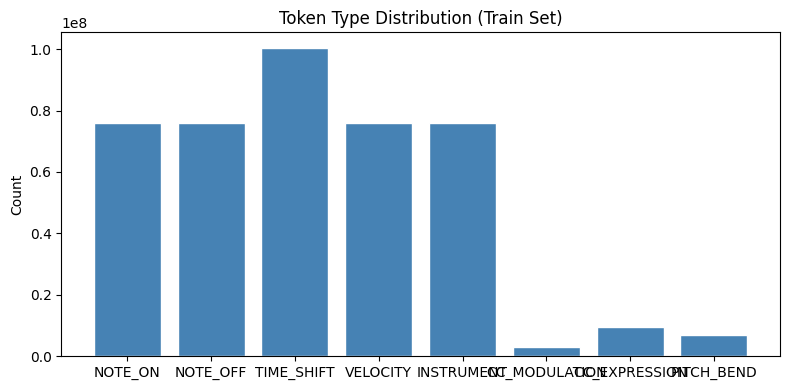

In [12]:
token_types = {
    'NOTE_ON'   : 0,
    'NOTE_OFF'  : 0,
    'TIME_SHIFT': 0,
    'VELOCITY'  : 0,
    'INSTRUMENT': 0,
    'CC_MODULATION': 0, # added these tokens for violin
    'CC_EXPRESSION': 0,
    'PITCH_BEND'   : 0,
}

for t in train_tokens:
    if t < NOTE_OFF_OFFSET:
        token_types['NOTE_ON'] += 1
    elif t < TIME_SHIFT_OFFSET:
        token_types['NOTE_OFF'] += 1
    elif t < VELOCITY_OFFSET:
        token_types['TIME_SHIFT'] += 1
    elif t < INSTRUMENT_OFFSET:
        token_types['VELOCITY'] += 1
    elif t < CC_MODULATION_OFFSET:
        token_types['INSTRUMENT'] += 1
    elif t < CC_EXPRESSION_OFFSET:
        token_types['CC_MODULATION'] += 1
    elif t < PITCH_BEND_OFFSET:
        token_types['CC_EXPRESSION'] += 1
    else:
        token_types['PITCH_BEND'] += 1

total = sum(token_types.values())
print("Token type distribution (train set):")
for k, v in token_types.items():
    print(f"  {k:<12}: {v:>10,}  ({100*v/total:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(token_types.keys(), token_types.values(), color='steelblue', edgecolor='white')
ax.set_title("Token Type Distribution (Train Set)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("eda_token_dist.png", dpi=150, bbox_inches='tight')
plt.show()


In [13]:
from torch.utils.data import Dataset, DataLoader

SEQ_LEN = 512

class MusicDataset(Dataset):
    def __init__(self, tokens):
        self.tokens = torch.tensor(tokens.astype(np.int64))

    def __len__(self):
        # each sample needs SEQ_LEN input tokens + 1 target token
        return len(self.tokens) - SEQ_LEN

    def __getitem__(self, idx):
        x = self.tokens[idx : idx + SEQ_LEN]          # input
        y = self.tokens[idx + 1 : idx + SEQ_LEN + 1]  # target (shifted by 1)
        return x, y

train_dataset = MusicDataset(train_tokens)
val_dataset   = MusicDataset(val_tokens)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val samples   : {len(val_dataset):,}")
print(f"Train batches : {len(train_loader):,}")

Train samples : 424,056,165
Val samples   : 72,048,978
Train batches : 13,251,756


## 6. Model

### Modeling: Causal Language Modeling over Token Sequences

**Task formulation**  
We treat symbolic music generation as a sequence modeling problem. The MIDI data is converted into a discrete token sequence using an event-based vocabulary (390 tokens covering NOTE_ON, NOTE_OFF, TIME_SHIFT, VELOCITY, and INSTRUMENT events). The model learns the autoregressive distribution:

$$p(x_1, x_2, \ldots, x_T) = \prod_{t=1}^{T} p(x_t \mid x_1, \ldots, x_{t-1})$$

At each step, the model predicts the next token given all previous tokens. Training minimizes cross-entropy loss.

**Why a Transformer?**  
Transformers are well-suited for music modeling because self-attention can capture long-range dependencies, training is parallelizable unlike RNNs, and there are strong empirical results on symbolic music (Music Transformer, PerformanceRNN).

**Tradeoffs and limitations**  
- Quadratic attention complexity limits context to `max_seq_len=512` tokens  
- Absolute positional encodings may not capture relative rhythmic relationships as well as relative attention (Huang et al., 2018)  
- No explicit musical structure imposed — harmony and rhythm must be learned purely from data


In [37]:
import torch.nn as nn

class MusicTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_dim, dropout, max_seq_len):
        super().__init__()
        self.embed_dim = embed_dim
        self.embedding    = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoding = nn.Embedding(max_seq_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc          = nn.Linear(embed_dim, vocab_size)
        self.max_seq_len = max_seq_len

    def forward(self, x):
        seq_len   = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        mask      = nn.Transformer.generate_square_subsequent_mask(seq_len, device=x.device)
        x = self.embedding(x) * math.sqrt(self.embed_dim) + self.pos_encoding(positions)
        x = self.transformer(x, mask=mask, is_causal=True)
        return self.fc(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = MusicTransformer(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = 256,
    num_heads   = 8,
    num_layers  = 4,
    ff_dim      = 1024,
    dropout     = 0.1,
    max_seq_len = 512,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Using device: cuda
Total parameters: 3,687,174


In [38]:
# sample_x, sample_y = next(iter(train_loader))
# print("X:", sample_x[0, :10])
# print("Y:", sample_y[0, :10])

## 7. Training

In [39]:
LEARNING_RATE  = 0.002
MAX_STEPS      = 20000
WARMUP_STEPS   = 1000
VAL_EVERY      = 1000
SAVE_EVERY     = 5000

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9)

def get_lr(step):
    if step < WARMUP_STEPS:
        return step / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / (MAX_STEPS - WARMUP_STEPS)
    return 0.5 * (1 + math.cos(math.pi * progress))

def evaluate(model, loader, max_batches=50):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i >= max_batches:
                break
            x, y   = x.to(device), y.to(device)
            logits = model(x)
            loss   = F.cross_entropy(logits.view(-1, VOCAB_SIZE), y.view(-1))
            total_loss += loss.item()
    model.train()
    return total_loss / min(max_batches, len(loader))

train_iter   = iter(train_loader)
step         = 0
train_losses = []
val_losses   = []

model.train()
pbar = tqdm(total=MAX_STEPS, desc="Training", unit="step")
while step < MAX_STEPS:
    try:
        x, y = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        x, y = next(train_iter)

    # update learning rate
    lr = LEARNING_RATE * get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    logits = model(x)
    loss   = F.cross_entropy(logits.view(-1, VOCAB_SIZE), y.view(-1))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    train_losses.append(loss.item())
    step += 1
    pbar.update(1)

    if step % VAL_EVERY == 0:
        val_loss = evaluate(model, val_loader)
        val_losses.append((step, val_loss))
        print(f"Step {step:6d} | lr: {lr:.6f} | train loss: {loss.item():.4f} | val loss: {val_loss:.4f}")

    if step % SAVE_EVERY == 0:
        torch.save(model.state_dict(), f"checkpoint_step{step}.pt")
        print(f"  → checkpoint saved")

print("Training complete.")


Training:   0%|          | 0/20000 [00:00<?, ?step/s]

Step   1000 | lr: 0.001998 | train loss: 2.5306 | val loss: 2.9120


Step   2000 | lr: 0.001986 | train loss: 2.2677 | val loss: 2.8096


Step   3000 | lr: 0.001946 | train loss: 2.1610 | val loss: 2.7204


Step   4000 | lr: 0.001880 | train loss: 2.1271 | val loss: 2.5709


...

Step  16000 | lr: 0.000211 | train loss: 1.9161 | val loss: 2.3347


Step  17000 | lr: 0.000121 | train loss: 1.7486 | val loss: 2.3314


Step  18000 | lr: 0.000054 | train loss: 1.9652 | val loss: 2.3221


Step  19000 | lr: 0.000014 | train loss: 1.7275 | val loss: 2.3239


Step  20000 | lr: 0.000000 | train loss: 1.8914 | val loss: 2.3228
  → checkpoint saved
Training complete.


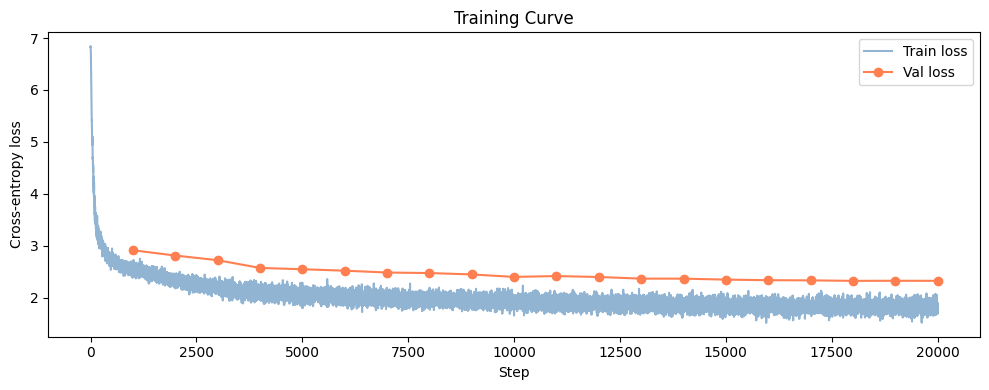

In [40]:
# Plot training loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, alpha=0.6, color='steelblue', label='Train loss')
if val_losses:
    val_steps, v_losses = zip(*val_losses)
    plt.plot(val_steps, v_losses, color='coral', marker='o', label='Val loss')
plt.xlabel("Step")
plt.ylabel("Cross-entropy loss")
plt.title("Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Generation

In [46]:
def generate(model, seed_tokens, n_tokens, temperature, top_k):
    model.eval()
    tokens = list(seed_tokens)

    with torch.no_grad():
        for _ in range(n_tokens):
            # use the last max_seq_len tokens as context
            context = tokens[-model.max_seq_len:]
            x       = torch.tensor(context, dtype=torch.long).unsqueeze(0).to(device)
            logits  = model(x)
            logits  = logits[:, -1, :] / temperature
            if top_k is not None:
                top_k_values, _ = torch.topk(logits, top_k)
                min_top_k = top_k_values[:, [-1]]
                logits[logits < min_top_k] = -float('Inf')
            probs   = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1).item()
            tokens.append(next_token)

    return tokens[len(seed_tokens):]

# use the first 100 tokens of training data as seed
seed      = train_tokens[:100].astype(np.int64).tolist()
generated = generate(model, seed, n_tokens=2500, temperature=1.1, top_k=50)
tokens_to_midi(generated, "symbolic_unconditioned.mid")
print(f"Generated {len(generated)} tokens")

Saved: symbolic_unconditioned.mid | piano notes: 379 | violin notes: 11
Generated 2500 tokens


## 9. Evaluation

### Evaluation

**What makes good generated music?**  
A good output should exhibit coherent pitch patterns, realistic rhythmic structure, instrument balance between piano and violin, and diversity. Objectively measuring these is an open problem — we use perplexity as a proxy and compare token/pitch distributions between real and generated music.

**Perplexity and its limitations**  
Perplexity measures how surprised the model is by held-out data — lower is better. However, low perplexity does not guarantee musical quality. We complement it with distributional comparisons.

**Baselines**  
- *Uniform random*: samples uniformly over all 390 tokens. Perplexity = 390.  
- *Unigram*: samples proportional to token frequency in the training set.  

A well-trained model should substantially outperform both.


### 9.1 Perplexity and Baselines

In [47]:
# Model perplexity on validation set
val_loss  = evaluate(model, val_loader, max_batches=100)
model_ppl = math.exp(val_loss)
print(f"Model val loss  : {val_loss:.4f}")
print(f"Model perplexity: {model_ppl:.2f}")

# Baseline 1: uniform random
uniform_loss = math.log(VOCAB_SIZE)
uniform_ppl  = VOCAB_SIZE
print(f"\nUniform baseline loss       : {uniform_loss:.4f}")
print(f"Uniform baseline perplexity : {uniform_ppl}")

# Baseline 2: unigram
token_counts     = np.bincount(train_tokens.astype(np.int64), minlength=VOCAB_SIZE)
token_probs      = token_counts / token_counts.sum()
val_token_counts = np.bincount(val_tokens.astype(np.int64),   minlength=VOCAB_SIZE)
val_probs_true   = val_token_counts / val_token_counts.sum()
unigram_loss     = -np.sum(val_probs_true * np.log(token_probs + 1e-10))
unigram_ppl      = math.exp(unigram_loss)
print(f"\nUnigram baseline loss       : {unigram_loss:.4f}")
print(f"Unigram baseline perplexity : {unigram_ppl:.2f}")

print("\n--- Summary ---")
print(f"{'Method':<20} {'Loss':>8} {'Perplexity':>12}")
print("-" * 42)
print(f"{'Uniform random':<20} {uniform_loss:>8.4f} {uniform_ppl:>12}")
print(f"{'Unigram':<20} {unigram_loss:>8.4f} {unigram_ppl:>12.2f}")
print(f"{'MusicTransformer':<20} {val_loss:>8.4f} {model_ppl:>12.2f}")


Model val loss  : 2.1862
Model perplexity: 8.90

Uniform baseline loss       : 6.6516
Uniform baseline perplexity : 774



Unigram baseline loss       : 4.4530
Unigram baseline perplexity : 85.88

--- Summary ---
Method                   Loss   Perplexity
------------------------------------------
Uniform random         6.6516          774
Unigram                4.4530        85.88
MusicTransformer       2.1862         8.90


### 9.2 Token Distribution: Generated vs Real

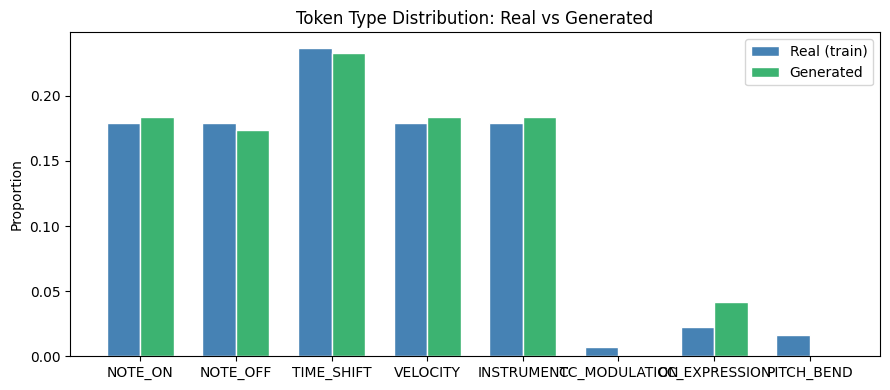

Real distribution:
  NOTE_ON     : 0.179
  NOTE_OFF    : 0.179
  TIME_SHIFT  : 0.237
  VELOCITY    : 0.179
  INSTRUMENT  : 0.179
  CC_MODULATION: 0.007
  CC_EXPRESSION: 0.023
  PITCH_BEND  : 0.017
Generated distribution:
  NOTE_ON     : 0.184
  NOTE_OFF    : 0.174
  TIME_SHIFT  : 0.233
  VELOCITY    : 0.184
  INSTRUMENT  : 0.184
  CC_MODULATION: 0.000
  CC_EXPRESSION: 0.042
  PITCH_BEND  : 0.000


In [53]:
# Generate a sample for evaluation
seed     = train_tokens[:50].astype(np.int64).tolist()
gen_tokens = generate(model, seed, n_tokens=5000, temperature=1.0, top_k=15)
gen_tokens = np.array(gen_tokens)

def get_type_counts(tokens):
    counts = {'NOTE_ON': 0, 'NOTE_OFF': 0, 'TIME_SHIFT': 0, 'VELOCITY': 0, 'INSTRUMENT': 0,
             'CC_MODULATION': 0, 'CC_EXPRESSION': 0, 'PITCH_BEND': 0 }
    for t in tokens:
        if t < NOTE_OFF_OFFSET:
            counts['NOTE_ON']    += 1
        elif t < TIME_SHIFT_OFFSET:
            counts['NOTE_OFF']   += 1
        elif t < VELOCITY_OFFSET:
            counts['TIME_SHIFT'] += 1
        elif t < INSTRUMENT_OFFSET:
            counts['VELOCITY']   += 1
        elif t < CC_MODULATION_OFFSET:
            counts['INSTRUMENT'] += 1
        elif t < CC_EXPRESSION_OFFSET:
            counts['CC_MODULATION'] += 1
        elif t < PITCH_BEND_OFFSET:
            counts['CC_EXPRESSION'] += 1
        else:
            counts['PITCH_BEND'] += 1
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

real_dist = get_type_counts(train_tokens)
gen_dist  = get_type_counts(gen_tokens)

labels = list(real_dist.keys())
real_vals = [real_dist[k] for k in labels]
gen_vals  = [gen_dist[k]  for k in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, real_vals, width, label='Real (train)', color='steelblue',     edgecolor='white')
ax.bar(x + width/2, gen_vals,  width, label='Generated',    color='mediumseagreen', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("Token Type Distribution: Real vs Generated")
ax.set_ylabel("Proportion")
ax.legend()
plt.tight_layout()
plt.savefig("eval_token_dist.png", dpi=150, bbox_inches='tight')
plt.show()

print("Real distribution:")
for k, v in real_dist.items():
    print(f"  {k:<12}: {v:.3f}")
print("Generated distribution:")
for k, v in gen_dist.items():
    print(f"  {k:<12}: {v:.3f}")


### 9.3 Pitch Distribution: Generated vs Real

/tmp/ipykernel_97/125537193.py:39: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


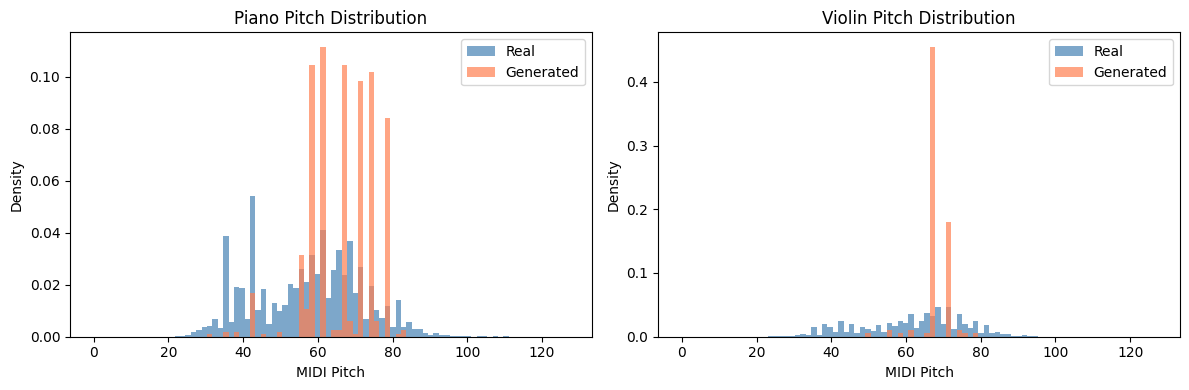

Real   piano  pitches — mean: 57.4  std: 14.4
Gen    piano  pitches — mean: 66.6  std: 8.5
Real   violin pitches — mean: 62.0  std: 13.9
Gen    violin pitches — mean: 67.9  std: 3.4


In [54]:
def get_pitch_dist(tokens, instrument_filter):
    pitches = []
    current_inst = PIANO_TOKEN
    for t in tokens:
        if t == PIANO_TOKEN or t == VIOLIN_TOKEN:
            current_inst = t
        elif NOTE_ON_OFFSET <= t < NOTE_OFF_OFFSET:
            if current_inst == instrument_filter:
                pitches.append(t - NOTE_ON_OFFSET)
    return np.array(pitches)

real_piano_pitches  = get_pitch_dist(train_tokens, PIANO_TOKEN)
real_violin_pitches = get_pitch_dist(train_tokens, VIOLIN_TOKEN)
gen_piano_pitches   = get_pitch_dist(gen_tokens,   PIANO_TOKEN)
gen_violin_pitches  = get_pitch_dist(gen_tokens,   VIOLIN_TOKEN)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Piano pitch distribution
axes[0].hist(real_piano_pitches, bins=88, range=(0,127), alpha=0.7, density=True,
             color='steelblue', label='Real')
axes[0].hist(gen_piano_pitches,  bins=88, range=(0,127), alpha=0.7, density=True,
             color='coral',     label='Generated')
axes[0].set_title("Piano Pitch Distribution")
axes[0].set_xlabel("MIDI Pitch")
axes[0].set_ylabel("Density")
axes[0].legend()

# Violin pitch distribution
axes[1].hist(real_violin_pitches, bins=88, range=(0,127), alpha=0.7, density=True,
             color='steelblue', label='Real')
axes[1].hist(gen_violin_pitches,  bins=88, range=(0,127), alpha=0.7, density=True,
             color='coral',     label='Generated')
axes[1].set_title("Violin Pitch Distribution")
axes[1].set_xlabel("MIDI Pitch")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig("eval_pitch_dist.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Real   piano  pitches — mean: {real_piano_pitches.mean():.1f}  std: {real_piano_pitches.std():.1f}")
print(f"Gen    piano  pitches — mean: {gen_piano_pitches.mean():.1f}  std: {gen_piano_pitches.std():.1f}")
print(f"Real   violin pitches — mean: {real_violin_pitches.mean():.1f}  std: {real_violin_pitches.std():.1f}")
print(f"Gen    violin pitches — mean: {gen_violin_pitches.mean():.1f}  std: {gen_violin_pitches.std():.1f}")
